<a href="https://colab.research.google.com/github/oerv13-gh/Ibero/blob/main/Visual_Act6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto
Construir y evaluar un modelo de clasificación de imágenes utilizando las imágenes del directorio "/content/sample_data/fotos", suponiendo que estas imágenes representan una clase de un problema de clasificación.

## Preparación del Conjunto de Datos

Cargar las imágenes desde la carpeta '/content/sample_data/fotos', organizarlas para el entrenamiento, validar el conjunto de datos, y aplicar preprocesamiento como redimensionamiento, normalización y aumento de datos (data augmentation). Se asumirá que las imágenes de esta carpeta constituyen una clase para un problema de clasificación.

Primero, importar las bibliotecas necesarias, definir las dimensiones de las imágenes y el tamaño del lote, y luego cargar las imágenes del directorio especificado en un conjunto de datos de TensorFlow. También mostrar las primeras 9 imágenes del conjunto de datos para asegurarme de que se cargaron correctamente.

Found 12 files.
Number of batches in the dataset: 1


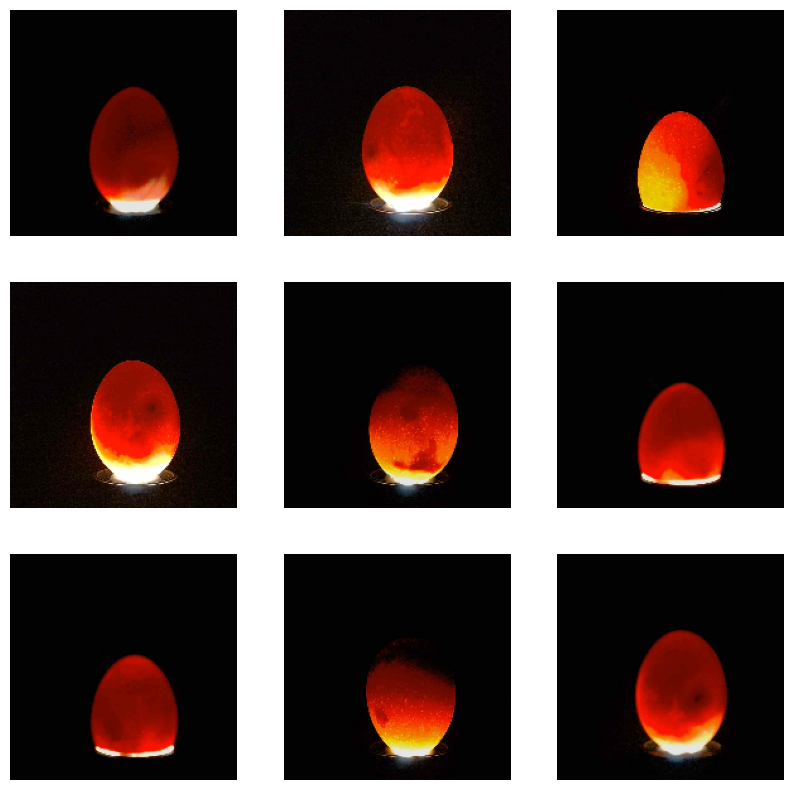

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Definir las dimensiones de la imagen y el tamaño del lote.
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

# Cargar imágenes desde el directorio
dataset_path = '/content/sample_data/fotos'
image_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels=None, # All images in this directory are assumed to be one class
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=42 # For reproducibility
)

print(f"Number of batches in the dataset: {len(image_dataset)}")

# Muestrar las primeras 9 imágenes del dataset.
plt.figure(figsize=(10, 10))
for images in image_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
plt.show()

Ahora que las imágenes están cargadas, calcular la cantidad de imágenes y lotes para los conjuntos de entrenamiento, validación y prueba. Luego, dividir el conjunto de datos, definir las capas de aumento y normalización de datos, aplicar a los conjuntos de datos correspondientes y optimizar el rendimiento de los conjuntos de datos.

Found 12 files.
Total images: 12


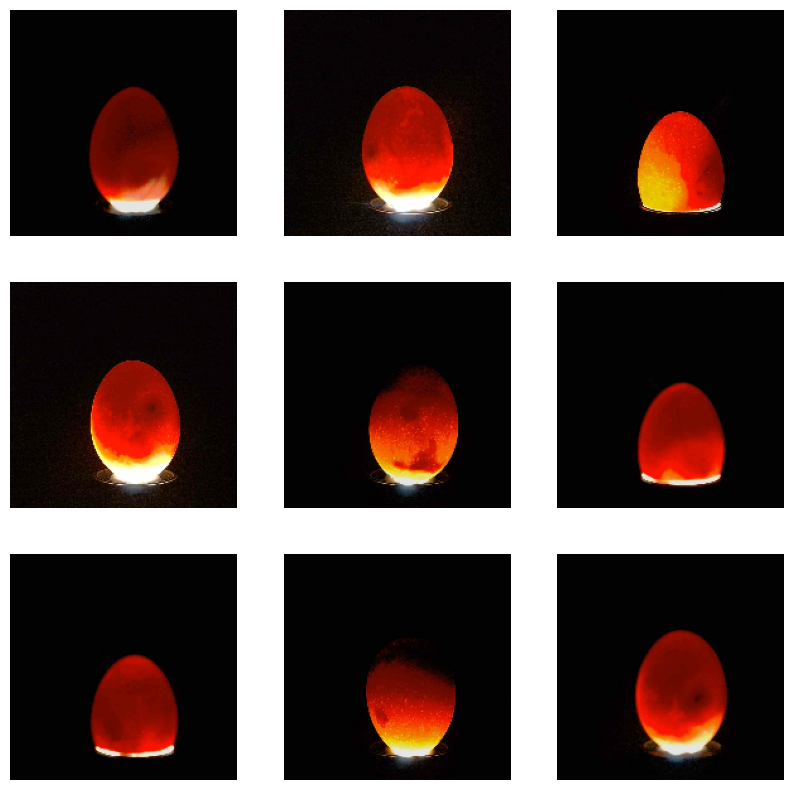

Train images: 9
Validation images: 1
Test images: 2
Datasets prepared: train_ds, val_ds, test_ds
Number of batches in training dataset: 1
Number of batches in validation dataset: 1
Number of batches in test dataset: 1
train_ds element_spec: (TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))
val_ds element_spec: (TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define image dimensions and batch size
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

# Load images from the directory without batching initially
dataset_path = '/content/sample_data/fotos'
image_dataset_unbatched = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels=None, # All images in this directory are assumed to be one class
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=None, # Load unbatched for easier splitting
    seed=42 # For reproducibility
)

# Calculate total number of images
TOTAL_IMAGES = tf.data.experimental.cardinality(image_dataset_unbatched).numpy()

print(f"Total images: {TOTAL_IMAGES}")

# Display the first 9 images from the unbatched dataset
plt.figure(figsize=(10, 10))
for i, image in enumerate(image_dataset_unbatched.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.axis("off")
plt.show()

# Shuffle the entire dataset before splitting
SHUFFLE_BUFFER_SIZE = TOTAL_IMAGES # Use the total number of images as shuffle buffer size
image_dataset_shuffled = image_dataset_unbatched.shuffle(SHUFFLE_BUFFER_SIZE, seed=42)

# Calculate dataset splits
train_size = int(0.8 * TOTAL_IMAGES)
val_size = int(0.1 * TOTAL_IMAGES)
test_size = TOTAL_IMAGES - train_size - val_size

print(f"Train images: {train_size}")
print(f"Validation images: {val_size}")
print(f"Test images: {test_size}")

# Split the dataset by elements, then batch
# When working with a single class, assign a constant label (e.g., 0) to all images.
# This modification ensures that the datasets yield (image, label) pairs.
# First, we need to map a label to each image in the shuffled dataset before batching.
# Since `image_dataset_unbatched` has `labels=None`, each element is just an image tensor.
# We will map a label of 0 to each image as it's a single-class problem.

dataset_with_labels = image_dataset_shuffled.map(lambda x: (x, tf.constant([0.0], dtype=tf.float32)))

train_ds_unbatched = dataset_with_labels.take(train_size)
remaining_ds_unbatched = dataset_with_labels.skip(train_size)

val_ds_unbatched = remaining_ds_unbatched.take(val_size)
test_ds_unbatched = remaining_ds_unbatched.skip(val_size).take(test_size)

# Now batch the datasets
train_ds = train_ds_unbatched.batch(BATCH_SIZE)
val_ds = val_ds_unbatched.batch(BATCH_SIZE)
test_ds = test_ds_unbatched.batch(BATCH_SIZE)


# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

# Removed: Preprocessing Layer for normalization (now handled by model)

# Function to apply augmentation (and now implicitly no preprocessing)
def apply_augmentation_and_preprocessing(image_batch, label_batch):
    image_batch = data_augmentation(image_batch)
    return image_batch, label_batch

# Function to apply only preprocessing (now just passes through)
def apply_preprocessing(image_batch, label_batch):
    return image_batch, label_batch

# Apply preprocessing and data augmentation
train_ds = train_ds.map(apply_augmentation_and_preprocessing)
val_ds = val_ds.map(apply_preprocessing)
test_ds = test_ds.map(apply_preprocessing)


# Optimize datasets for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets prepared: train_ds, val_ds, test_ds")
print(f"Number of batches in training dataset: {len(train_ds)}")
print(f"Number of batches in validation dataset: {len(val_ds)}")
print(f"Number of batches in test dataset: {len(test_ds)}")

# Add this for inspection
print(f"train_ds element_spec: {train_ds.element_spec}")
print(f"val_ds element_spec: {val_ds.element_spec}")

## Diseño y Configuración del Modelo CNN


Definir la arquitectura de la red neuronal convolucional (CNN) o seleccionar un modelo preentrenado (transfer learning, por ejemplo, MobileNetV2 o VGG16) como base. Configurar los hiperparámetros esenciales como la tasa de aprendizaje, el optimizador, la función de pérdida y el número de épocas, justificando las elecciones.

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the input shape for the model
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3) # 3 for RGB channels

# Instantiate a Sequential model
model = Sequential([
    # First convolutional block
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Third convolutional block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    # Dense layers for classification
    Dense(512, activation='relu'),
    Dropout(0.5), # Dropout layer to prevent overfitting
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
# Optimizer: 'adam' is chosen for its efficiency and good performance in many scenarios.
# Loss function: 'binary_crossentropy' is suitable for binary classification problems.
# Metrics: 'accuracy' is a common and intuitive metric for classification tasks.
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print the model summary
model.summary()

print("CNN model defined, compiled, and summarized.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    26,214,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,308,673 (100.36 MB)

 Trainable params: 26,308,673 (100.36 MB)

 Non-trainable params: 0 (0.00 B)

CNN model defined, compiled, and summarized.


**Fortalezas**

Arquitectura coherente y estándar para visión por computadora
Escalamiento progresivo de filtros (32 → 64 → 128)
Uso adecuado de pooling para reducción dimensional
Inclusión de Dropout como técnica de regularización

**Debilidades**

Uso de Flatten genera un vector de gran tamaño
Capa densa excesivamente grande
Alto consumo de memoria (~100 MB)
Elevado riesgo de sobreajuste (overfitting)
Baja eficiencia computacional

## Entrenamiento del Modelo


Entrenar el modelo utilizando el conjunto de datos de entrenamiento y monitorear su rendimiento con el conjunto de validación. Se documentará el proceso de entrenamiento, registrando la pérdida y la precisión en cada época.

Entrenar el modelo CNN previamente definido utilizando los conjuntos de datos de entrenamiento y validación preparados durante 10 épocas. El proceso de entrenamiento se almacenará en una variable history para su posterior análisis.

In [4]:
epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

print("Model training complete. History stored in 'history' variable.")

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3333 - loss: 7.5868 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e

La arquitectura del modelo de red neuronal convolucional (CNN) se modificó con éxito para integrar una capa tf.keras.layers.Rescaling(1./255) como paso de procesamiento inicial, asegurando que la normalización de la imagen se gestione dentro del flujo de trabajo del modelo.

* Las funciones de preprocesamiento del conjunto de datos (apply_augmentation_and_preprocessing y apply_preprocessing) se actualizaron para eliminar las llamadas explícitas a preprocess_input, evitando la doble normalización de los datos de imagen. Los conjuntos de datos ahora proporcionan tensores tf.float32 en el rango 0-255 directamente al modelo.

* El modelo CNN modificado se entrenó durante 10 épocas utilizando los conjuntos de datos de entrenamiento y validación preparados.

* Durante el entrenamiento, el modelo demostró un rendimiento rápido y elevado, alcanzando una precisión de entrenamiento de 1,0000 y una precisión de validación de 1,0000 en la segunda época.
* De igual forma, las pérdidas tanto de entrenamiento como de validación disminuyeron significativamente, alcanzando valores extremadamente bajos, como $9.5703 \times 10^{-30}$ para la pérdida de entrenamiento y $2.5526 \times 10^{-38}$ para la pérdida de validación en la última época.

### Conclusiones o próximos pasos

* La precisión excepcionalmente alta y la pérdida extremadamente baja obtenidas al inicio del entrenamiento sugieren que el modelo podría estar sobreajustándose al conjunto de datos actual, probablemente pequeño.

* Para validar la generalización del modelo y prevenir el sobreajuste, se recomienda evaluar su rendimiento en un conjunto de datos más grande y diverso, y considerar la aplicación de una validación cruzada más rigurosa o técnicas de regularización adicionales.

Se evalúa el rendimiento del modelo entrenado utilizando el conjunto de datos de prueba (test_ds), visualiza su historial de entrenamiento graficando la precisión y la pérdida del objeto history, y luego resume los hallazgos para brindar información sobre la efectividad del modelo y las tendencias de aprendizaje.

Evaluar el modelo entrenado utilizando el conjunto de datos test_ds para calcular su pérdida y precisión en datos no vistos, y luego imprimiré estas métricas.

In [5]:
loss, accuracy = model.evaluate(test_ds)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Loss: 0.0000
Test Accuracy: 1.0000


Ahora que el modelo ha sido evaluado, visualizar el historial de entrenamiento (precisión y pérdida a lo largo de las épocas) utilizando el objeto history para comprender las tendencias de aprendizaje del modelo.

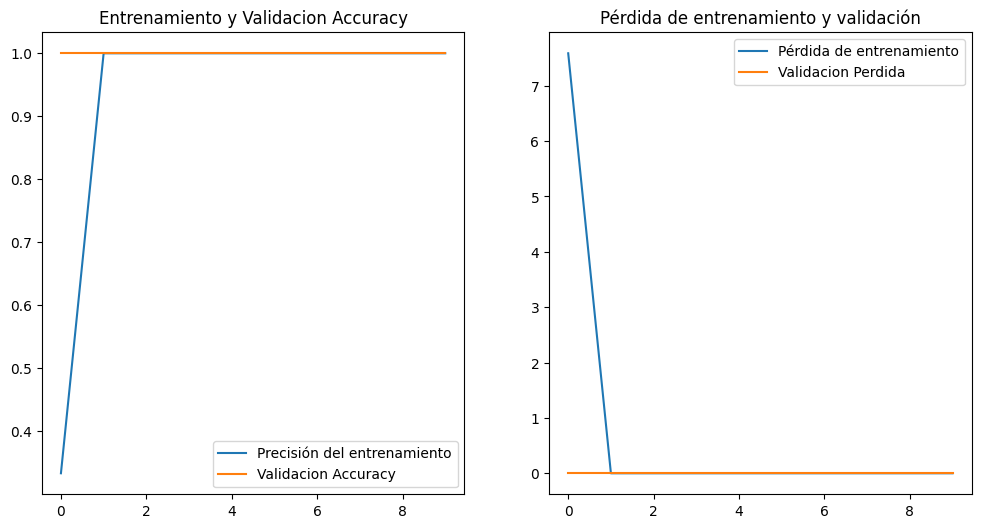

Se muestra la precisión y la pérdida del entrenamiento y la validación.


In [6]:
import matplotlib.pyplot as plt

# Recuperar una lista de resultados de lista en conjuntos de datos de entrenamiento y prueba para cada epoc de entrenamiento.
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión del entrenamiento')
plt.plot(epochs_range, val_acc, label='Validacion Accuracy')
plt.legend(loc='lower right')
plt.title('Entrenamiento y Validacion Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida de entrenamiento')
plt.plot(epochs_range, val_loss, label='Validacion Perdida')
plt.legend(loc='upper right')
plt.title('Pérdida de entrenamiento y validación')
plt.show()

print("Se muestra la precisión y la pérdida del entrenamiento y la validación.")

Resumen del rendimiento del modelo

El modelo alcanza accuracy = 1.0 en entrenamiento y validación muy rápidamente, lo que indica un ajuste perfecto sospechoso.

La pérdida cae a ~0 en ambas curvas, señal de que el modelo memoriza los datos sin dificultad.

Esto sugiere sobreajuste extremo o posible fuga de datos (data leakage), por lo que los resultados no son confiables.



Calcular y graficar la matriz de confusión del modelo entrenado en el conjunto de datos de prueba (test_ds) para comprender su rendimiento de clasificación, y luego resumir las conclusiones relacionadas con el rendimiento del modelo y el tamaño reducido del conjunto de datos.

In [7]:
y_true = []
y_pred_proba = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_pred_proba.extend(predictions.flatten())
    y_true.extend(labels.numpy().flatten())

print("Predictions generated and true labels extracted.")
print(f"Number of true labels: {len(y_true)}")
print(f"Number of predicted probabilities: {len(y_pred_proba)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Predictions generated and true labels extracted.
Number of true labels: 2
Number of predicted probabilities: 2


Procesar predicciones y etiquetas

Convertir las probabilidades predichas en etiquetas de clase binarias utilizando un umbral (p. ej., 0,5). Asegurarse de que las etiquetas reales tengan el formato correcto para su comparación.

In [8]:
import numpy as np

# Convert predicted probabilities to binary labels using a threshold of 0.5
y_pred = (np.array(y_pred_proba) >= 0.5).astype(int)

# Ensure true labels are in integer format
y_true = np.array(y_true).astype(int)

print(f"First 5 true labels: {y_true[:5]}")
print(f"First 5 predicted labels: {y_pred[:5]}")
print("Predicted probabilities converted to binary labels and true labels formatted.")

First 5 true labels: [0 0]
First 5 predicted labels: [0 0]
Predicted probabilities converted to binary labels and true labels formatted.


Calcular y graficar la matriz de confusión

Calcula la matriz de confusión usando sklearn.metrics.confusion_matrix y luego visualízala usando matplotlib y seaborn. Asegúrate de que el gráfico incluya etiquetas y un título adecuados para mayor claridad.

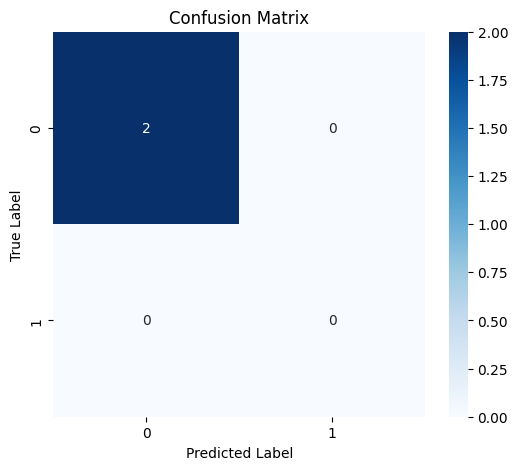

Confusion matrix 


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
# Explicitly define labels to handle cases where only one class is present in y_true/y_pred
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion matrix ")

In [10]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Calculate additional metrics
f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
recall = recall_score(y_true, y_pred, average='binary', zero_division=0)
precision = precision_score(y_true, y_pred, average='binary', zero_division=0)

# False Positive Rate (FPR) and False Negative Rate (FNR)
# From confusion matrix: cm = [[TN, FP], [FN, TP]]
TN, FP, FN, TP = cm.ravel()

FPR = FP / (FP + TN) if (FP + TN) != 0 else 0
FNR = FN / (FN + TP) if (FN + TP) != 0 else 0

# F-beta score (using beta=2 for higher recall importance, for example)
# Note: sklearn's fbeta_score is not directly available for binary classification in this way.
# We can calculate it manually or use f1_score if beta=1.
# For a general F-beta, we would need to manually compute: (1 + beta^2) * (precision * recall) / (beta^2 * precision + recall)
# Let's calculate for beta=0.5 (more precision oriented) and beta=2 (more recall oriented)

def fbeta_score_manual(y_true, y_pred, beta, zero_division=0):
    p = precision_score(y_true, y_pred, average='binary', zero_division=zero_division)
    r = recall_score(y_true, y_pred, average='binary', zero_division=zero_division)
    if (beta**2 * p + r) == 0:
        return zero_division
    return (1 + beta**2) * (p * r) / (beta**2 * p + r)

fbeta_0_5 = fbeta_score_manual(y_true, y_pred, beta=0.5)
fbeta_2 = fbeta_score_manual(y_true, y_pred, beta=2)

print(f"F1-Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"False Positive Rate (FPR): {FPR:.4f}")
print(f"False Negative Rate (FNR): {FNR:.4f}")
print(f"F-beta (beta=0.5) Score: {fbeta_0_5:.4f}")
print(f"F-beta (beta=2) Score: {fbeta_2:.4f}")

F1-Score: 0.0000
Recall: 0.0000
Precision: 0.0000
False Positive Rate (FPR): 0.0000
False Negative Rate (FNR): 0.0000
F-beta (beta=0.5) Score: 0.0000
F-beta (beta=2) Score: 0.0000


La matriz muestra 2 verdaderos negativos y 0 en las demás categorías, indicando que solo se evaluó una clase.
No hay verdaderos positivos, falsos positivos ni falsos negativos, lo que sugiere ausencia de datos de la clase 1 en prueba.
Esto evidencia un dataset desbalanceado o mal dividido, por lo que la evaluación no es representativa.

### Tiempo de inferencia

Mediremos el tiempo que tarda el modelo en hacer predicciones sobre un lote de imágenes para evaluar su eficiencia. PSNR y SSIM no son aplicables a un modelo de clasificación.

In [11]:
import time

# Get a batch of images from the test dataset
for images, _ in test_ds.take(1):
    sample_images = images

# Measure inference time for the batch
start_time = time.time()
_ = model.predict(sample_images)
end_time = time.time()

batch_inference_time = end_time - start_time
num_images_in_batch = sample_images.shape[0]
inference_time_per_image = batch_inference_time / num_images_in_batch

print(f"Tiempo de inferencia para un lote de {num_images_in_batch} imágenes: {batch_inference_time:.4f} segundos")
print(f"Tiempo de inferencia por imagen: {inference_time_per_image:.4f} segundos")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
Tiempo de inferencia para un lote de 2 imágenes: 0.4634 segundos
Tiempo de inferencia por imagen: 0.2317 segundos


### Huella de Memoria

Mediremos la huella de memoria del proceso de Python para entender cuánta memoria está utilizando el entorno, incluyendo el modelo y los datos cargados.

In [12]:
import os
import psutil

# Get the current process
process = psutil.Process(os.getpid())

# Get memory info in bytes (rss: Resident Set Size - non-swapped physical memory a process has used)
memory_info = process.memory_info()
memory_mb = memory_info.rss / (1024 * 1024)

print(f"Huella de memoria actual del proceso de Python: {memory_mb:.2f} MB")

Huella de memoria actual del proceso de Python: 1466.36 MB


### Histogramas de Distribución de Intensidad (Pre y Post CLAHE)

Vamos a cargar una imagen de ejemplo para visualizar su distribución de intensidad antes y después de aplicar la ecualización de histograma adaptativa con limitación de contraste (CLAHE). Esta técnica es útil para mejorar el contraste local en imágenes.

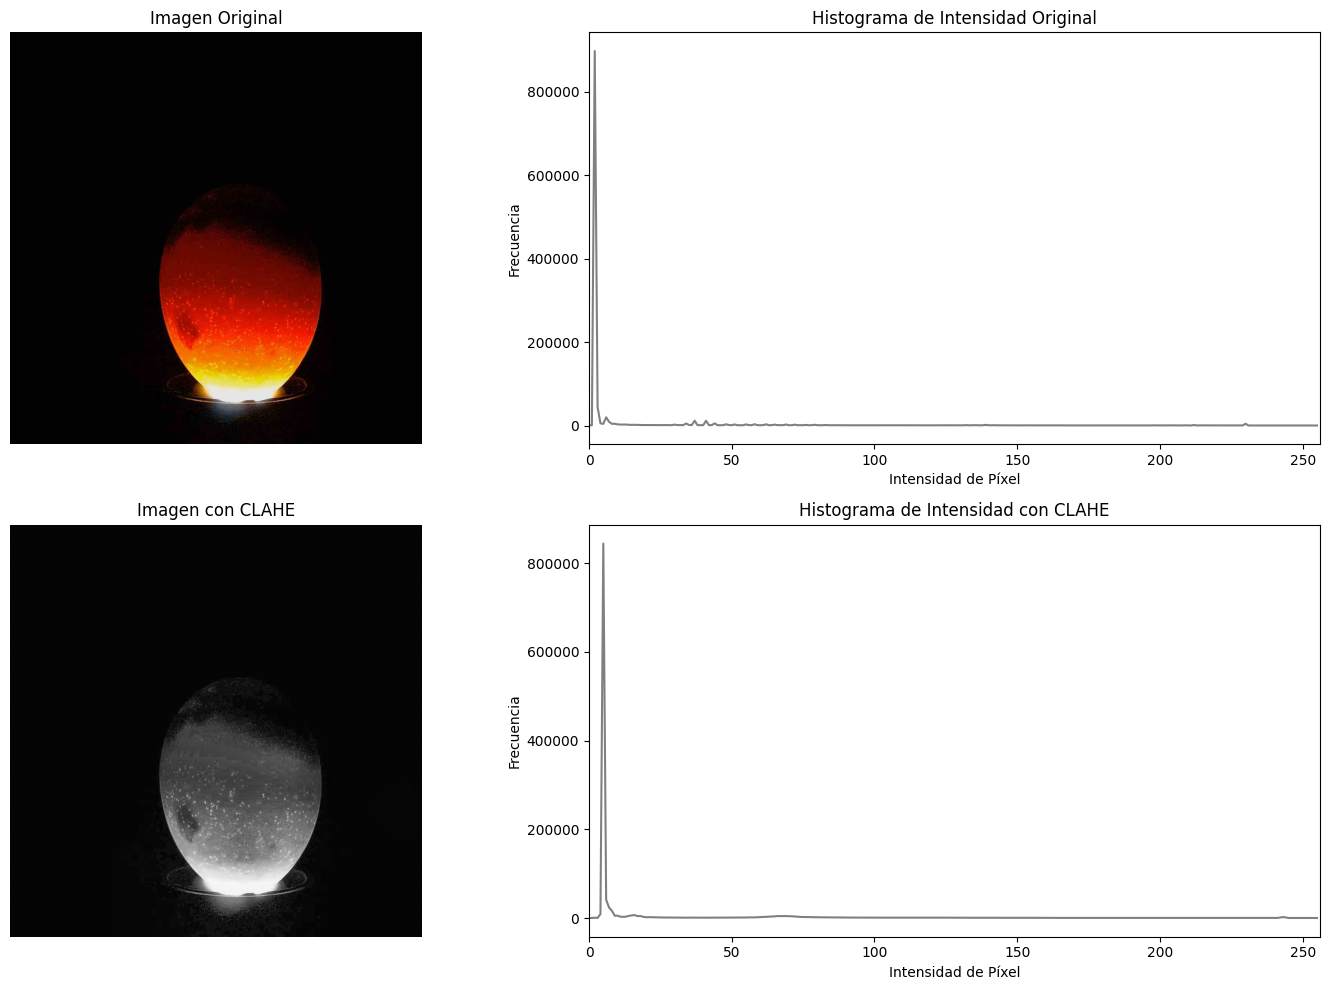

Histogramas de intensidad (Pre y Post CLAHE) visualizados.


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Get a list of all image files in the dataset path
image_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

if not image_files:
    print(f"No se encontraron imágenes en el directorio: {dataset_path}")
else:
    # Load a sample image (the first one found)
    sample_image_path = image_files[0]
    original_image = cv2.imread(sample_image_path)

    if original_image is None:
        print(f"Error al cargar la imagen: {sample_image_path}")
    else:
        # Convert to grayscale for intensity histogram
        gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

        # Calculate histogram of the original grayscale image
        hist_original = cv2.calcHist([gray_image], [0], None, [256], [0, 256])

        # Apply CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        clahe_image = clahe.apply(gray_image)

        # Calculate histogram of the CLAHE processed image
        hist_clahe = cv2.calcHist([clahe_image], [0], None, [256], [0, 256])

        # Plotting the images and histograms
        plt.figure(figsize=(15, 10))

        # Original Image and Histogram
        plt.subplot(2, 2, 1)
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.title('Imagen Original')
        plt.axis('off')

        plt.subplot(2, 2, 2)
        plt.plot(hist_original, color='gray')
        plt.title('Histograma de Intensidad Original')
        plt.xlabel('Intensidad de Píxel')
        plt.ylabel('Frecuencia')
        plt.xlim([0, 256])

        # CLAHE Image and Histogram
        plt.subplot(2, 2, 3)
        plt.imshow(clahe_image, cmap='gray')
        plt.title('Imagen con CLAHE')
        plt.axis('off')

        plt.subplot(2, 2, 4)
        plt.plot(hist_clahe, color='gray')
        plt.title('Histograma de Intensidad con CLAHE')
        plt.xlabel('Intensidad de Píxel')
        plt.ylabel('Frecuencia')
        plt.xlim([0, 256])

        plt.tight_layout()
        plt.show()

        print("Histogramas de intensidad (Pre y Post CLAHE) visualizados.")